In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('creditcard.csv')

# Look at the first few rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Check class distribution
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


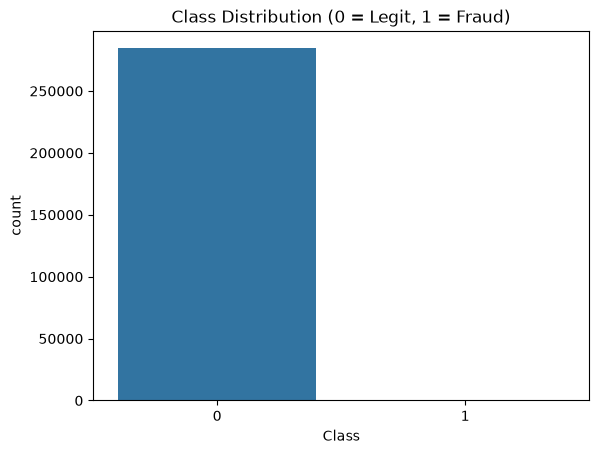

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()

In [4]:
# Check for missing values
print("Missing values:\n", df.isnull().sum().sum())

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Missing values:
 0
Duplicate rows: 1081


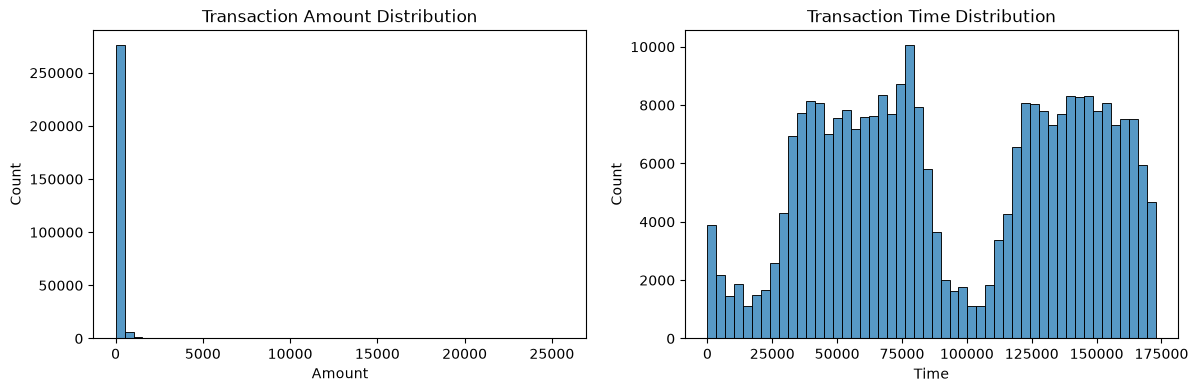

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')

sns.histplot(df['Time'], bins=50, ax=axes[1])
axes[1].set_title('Transaction Time Distribution')

plt.show()

In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

# Confirm removal
print("New shape:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

New shape: (283726, 31)
Duplicate rows remaining: 0


In [7]:
# Compare Amount statistics: Fraud vs Legit
print("Legit transactions - Amount stats:")
print(df[df['Class'] == 0]['Amount'].describe())

print("\nFraud transactions - Amount stats:")
print(df[df['Class'] == 1]['Amount'].describe())

Legit transactions - Amount stats:
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

Fraud transactions - Amount stats:
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


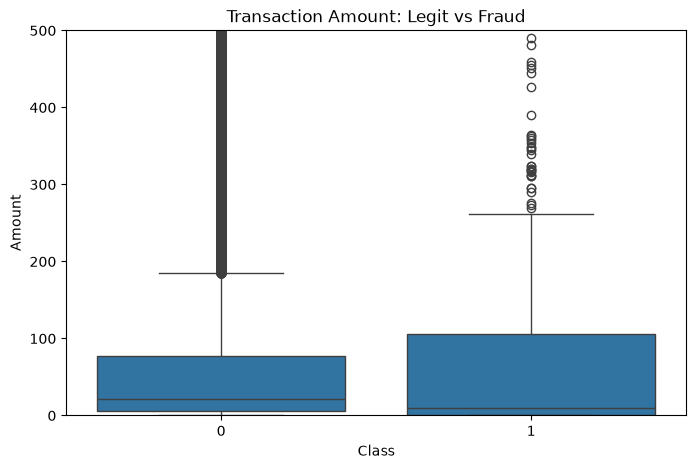

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount: Legit vs Fraud')
plt.ylim(0, 500)  # zoom in, since a few huge outliers would squash the chart
plt.show()

In [9]:
from sklearn.preprocessing import RobustScaler

scaler_amount = RobustScaler()
scaler_time = RobustScaler()

df['scaled_amount'] = scaler_amount.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler_time.fit_transform(df['Time'].values.reshape(-1, 1))

df = df.drop(['Amount', 'Time'], axis=1)

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

print(X.shape, y.shape)

(283726, 30) (283726,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nFraud ratio in train:", y_train.mean())
print("Fraud ratio in test:", y_test.mean())

Train shape: (226980, 30)
Test shape: (56746, 30)

Fraud ratio in train: 0.0016653449643140364
Fraud ratio in test: 0.0016741268107003137


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_smote.value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

[[55194  1457]
 [   12    83]]


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

[[56644     7]
 [   22    73]]


In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.78      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746

[[56624    27]
 [   21    74]]


In [16]:
from sklearn.metrics import average_precision_score

# Get probability scores (not just predictions) for each model
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("Logistic Regression PR-AUC:", average_precision_score(y_test, y_prob_log))
print("Random Forest PR-AUC:", average_precision_score(y_test, y_prob_rf))
print("XGBoost PR-AUC:", average_precision_score(y_test, y_prob_xgb))

Logistic Regression PR-AUC: 0.6714349230477037
Random Forest PR-AUC: 0.8137841991111054
XGBoost PR-AUC: 0.8060410230346489


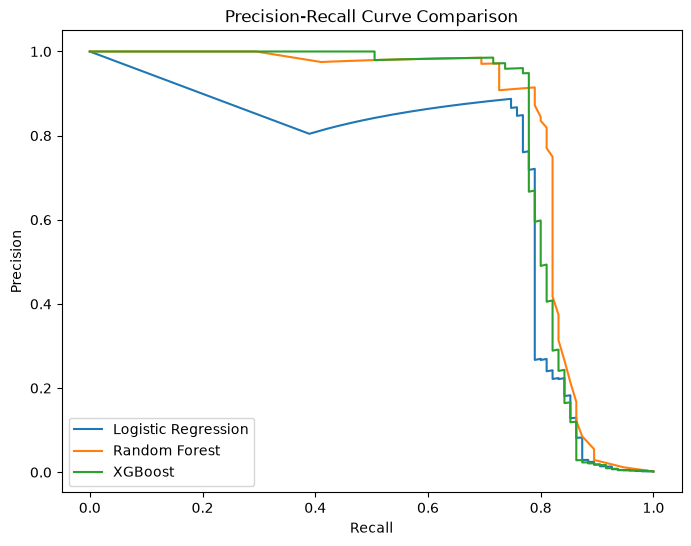

In [17]:
from sklearn.metrics import precision_recall_curve

precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall_log, precision_log, label='Logistic Regression')
plt.plot(recall_rf, precision_rf, label='Random Forest')
plt.plot(recall_xgb, precision_xgb, label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

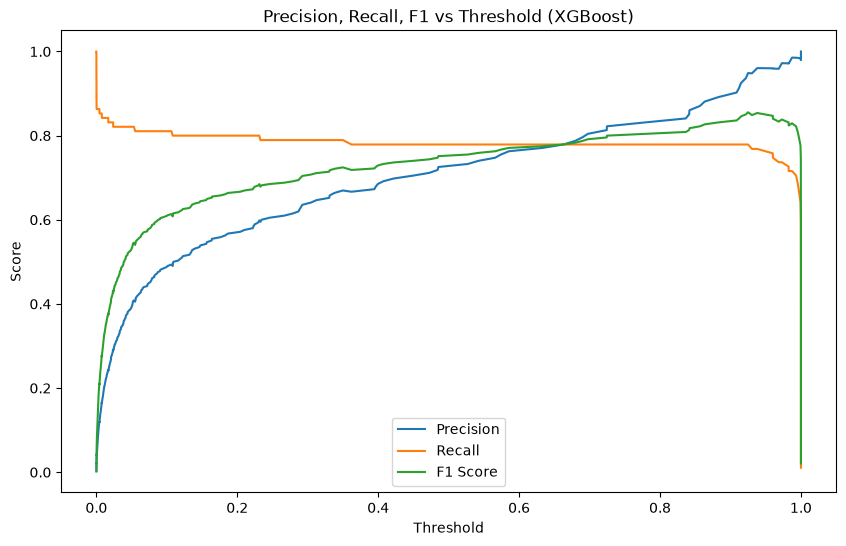

In [18]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

# F1 score at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold (XGBoost)')
plt.legend()
plt.show()

In [19]:
import numpy as np

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision at this threshold: {precision[best_idx]:.4f}")
print(f"Recall at this threshold: {recall[best_idx]:.4f}")
print(f"F1 score at this threshold: {f1_scores[best_idx]:.4f}")

Best threshold: 0.9249
Precision at this threshold: 0.9487
Recall at this threshold: 0.7789
F1 score at this threshold: 0.8555


In [20]:
y_pred_optimal = (y_prob_xgb >= best_threshold).astype(int)

print("Confusion Matrix with optimized threshold:")
print(confusion_matrix(y_test, y_pred_optimal))
print("\nClassification Report with optimized threshold:")
print(classification_report(y_test, y_pred_optimal))

Confusion Matrix with optimized threshold:
[[56647     4]
 [   21    74]]

Classification Report with optimized threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.78      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [21]:
# Try a lower threshold to see the tradeoff
lower_threshold = 0.3
y_pred_recall_focused = (y_prob_xgb >= lower_threshold).astype(int)

print(f"Threshold: {lower_threshold}")
print(confusion_matrix(y_test, y_pred_recall_focused))
print(classification_report(y_test, y_pred_recall_focused))

Threshold: 0.3
[[56609    42]
 [   20    75]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.64      0.79      0.71        95

    accuracy                           1.00     56746
   macro avg       0.82      0.89      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [22]:
print(df.columns.tolist())

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'scaled_amount', 'scaled_time']


In [23]:
import joblib
import json

joblib.dump(xgb, 'fraud_model.pkl')
joblib.dump(scaler_amount, 'scaler_amount.pkl')
joblib.dump(scaler_time, 'scaler_time.pkl')

with open('threshold.json', 'w') as f:
    json.dump({'threshold': float(best_threshold)}, f)

print("Model and both scalers saved successfully!")

Model and both scalers saved successfully!


In [24]:
# Get one real fraud example and one real legit example from test data
fraud_example = X_test[y_test == 1].iloc[0]
legit_example = X_test[y_test == 0].iloc[0]

print("FRAUD EXAMPLE:")
print(fraud_example.to_dict())

print("\nLEGIT EXAMPLE:")
print(legit_example.to_dict())

FRAUD EXAMPLE:
{'V1': -1.54878809850026, 'V2': 1.80869795041448, 'V3': -0.953509033832342, 'V4': 2.21308539346999, 'V5': -2.01572779170327, 'V6': -0.913456844516923, 'V7': -2.35601298316433, 'V8': 1.19716896702387, 'V9': -1.67837405659509, 'V10': -3.53865023182429, 'V11': 3.1020899271543, 'V12': -3.99337305447702, 'V13': -1.93741062327519, 'V14': -3.82289410599595, 'V15': 0.830970110708369, 'V16': -2.47535885382925, 'V17': -5.21187516766885, 'V18': -0.413871678166879, 'V19': 0.933262164554872, 'V20': 0.390785963777347, 'V21': 0.855138263312025, 'V22': 0.77474482148342, 'V23': 0.0590371520063436, 'V24': 0.343199807900813, 'V25': -0.468937928609185, 'V26': -0.278337986906642, 'V27': 0.625922215184372, 'V28': 0.395573378256676, 'scaled_amount': 0.7640105687665135, 'scaled_time': -0.1237877269936217}

LEGIT EXAMPLE:
{'V1': 1.2288211502379, 'V2': -0.0634077165201056, 'V3': 0.274145142235826, 'V4': 0.647465021810117, 'V5': -0.0481345611508765, 'V6': 0.372073028593297, 'V7': -0.22423058741343

In [25]:
# Get the raw Amount and Time for the same fraud/legit examples
# We need the original dataframe indices to look these up

fraud_idx = X_test[y_test == 1].index[0]
legit_idx = X_test[y_test == 0].index[0]

# Inverse-transform back to original dollar amount and time
fraud_raw_amount = scaler_amount.inverse_transform([[X_test.loc[fraud_idx, 'scaled_amount']]])[0][0]
fraud_raw_time = scaler_time.inverse_transform([[X_test.loc[fraud_idx, 'scaled_time']]])[0][0]

legit_raw_amount = scaler_amount.inverse_transform([[X_test.loc[legit_idx, 'scaled_amount']]])[0][0]
legit_raw_time = scaler_time.inverse_transform([[X_test.loc[legit_idx, 'scaled_time']]])[0][0]

print(f"FRAUD - raw amount: {fraud_raw_amount}, raw time: {fraud_raw_time}")
print(f"LEGIT - raw amount: {legit_raw_amount}, raw time: {legit_raw_time}")

FRAUD - raw amount: 76.94, raw time: 74159.0
LEGIT - raw amount: 11.5, raw time: 61290.0
